In [1]:
import sys
from pathlib import Path
import pandas as pd

sys.path.insert(0, str(Path(r"C:\Users\taylorhearn\git_repos\vascumap\bel_vascumap")))
from plotting import combine_outputs, pca_plots, plot_experiment_comparisons

# ── Experiment-specific config ────────────────────────────────────────────────
CONDITION_COLORS = {"iris": "red", "poppy": "dodgerblue", "tulip": "darkorange", "bloom":"limegreen", "rose":"gold", "daisy":"darkviolet"}

def find_condition(row):
    name = str(row["image_name"]).lower()
    if "iris" in name:
        return "iris"
    elif "poppy" in name:
        return "poppy"
    elif "tulip" in name:
        return "tulip"
    elif "bloom" in name:
        return "bloom"
    elif "rose" in name:
        return "rose"
    elif "daisy" in name:
        return "daisy"
    return "NA"

In [2]:
root_dir = Path(r"Z:\Bel\Individual_Vascumap_Outputs\Avalon_Vascumap\To_Analyse")
output_dir = root_dir.parent / f"{root_dir.name}_output_data"
output_dir.mkdir(parents=True, exist_ok=True)

combined_analysis_metrics, combined_branch_metrics = combine_outputs(root_dir)
print(combined_analysis_metrics.shape)

Found extra uncategorised csv Z:\Bel\Individual_Vascumap_Outputs\Avalon_Vascumap\To_Analyse\20260416_Bloom_Bloom_F_D1_Merged_img5\20260416_Bloom_Bloom_F_D1_Merged_img5_all_morphological_params.csv
Found extra uncategorised csv Z:\Bel\Individual_Vascumap_Outputs\Avalon_Vascumap\To_Analyse\20260416_Bloom_R 2_Merged_img6\20260416_Bloom_R 2_Merged_img6_all_morphological_params.csv
Found extra uncategorised csv Z:\Bel\Individual_Vascumap_Outputs\Avalon_Vascumap\To_Analyse\20260416_Bloom_R 3_Merged_img7\20260416_Bloom_R 3_Merged_img7_all_morphological_params.csv
Found extra uncategorised csv Z:\Bel\Individual_Vascumap_Outputs\Avalon_Vascumap\To_Analyse\20260416_Bloom_R 5_Merged_img9\20260416_Bloom_R 5_Merged_img9_all_morphological_params.csv
Found extra uncategorised csv Z:\Bel\Individual_Vascumap_Outputs\Avalon_Vascumap\To_Analyse\20260416_Daisy_R 1_Merged_img4\20260416_Daisy_R 1_Merged_img4_all_morphological_params.csv
Found extra uncategorised csv Z:\Bel\Individual_Vascumap_Outputs\Avalon

In [3]:
COLS_TO_DROP = [
    "median_sprout_and_branch_median_cs_area_um2",
    "median_internal_pore_area_um2",
    "p90_minus_p10_internal_pore_area_um2",
    "total_vessel_length_um",
]
combined_analysis_metrics_minimal = combined_analysis_metrics.drop(columns=COLS_TO_DROP)
combined_analysis_metrics_minimal["experiment"] = combined_analysis_metrics_minimal.apply(find_condition, axis=1)
print(f"{len(combined_analysis_metrics_minimal.image_name.unique())} unique images")

32 unique images


In [9]:
_COUNT_COLS = [
    "total_number_of_sprouts",
    "total_number_of_branches",
    "total_number_of_junctions",
    "total_number_of_edges",
    "total_number_of_nodes",
]
_VOL_COL = "convex_hull_volume_um3"

for _df in (combined_analysis_metrics, combined_analysis_metrics_minimal):
    for _c in _COUNT_COLS:
        _df[f"{_c}_per_um3"] = _df[_c] / _df[_VOL_COL]
    _df.drop(columns=_COUNT_COLS, inplace=True)

# Persist the updated combined CSV in place
combined_analysis_metrics.to_csv(root_dir / "combined_analysis_metrics.csv", index=False)
print("Replaced raw counts with per-um3 normalised values and updated CSV.")


Replaced raw counts with per-um3 normalised values and updated CSV.


In [13]:
combined_analysis_metrics.columns

Index(['image_name', 'source_file', 'image_index', 'chip_volume_um3',
       'convex_hull_volume_um3', 'vessel_volume_um3', 'vessel_volume_fraction',
       'total_vessel_length_um', 'vessel_length_per_chip_volume_um_inverse2',
       'sprouts_per_vessel_length_um_inverse',
       'junctions_per_vessel_length_um_inverse', 'skeleton_fractal_dimension',
       'skeleton_lacunarity', 'median_sprout_and_branch_orientation_deg',
       'p90_minus_p10_sprout_and_branch_orientation_deg',
       'median_sprout_and_branch_median_cs_area_um2',
       'p90_minus_p10_sprout_and_branch_median_cs_area_um2',
       'median_sprout_and_branch_length_um',
       'p90_minus_p10_sprout_and_branch_length_um',
       'median_junction_dist_nearest_junction_um',
       'p90_minus_p10_junction_dist_nearest_junction_um',
       'median_sprout_dist_nearest_endpoint_um',
       'p90_minus_p10_sprout_dist_nearest_endpoint_um',
       'average_vessel_volume_um3', 'median_internal_pore_area_um2',
       'p90_minus_p

In [14]:
combined_analysis_metrics[combined_analysis_metrics_minimal["experiment"]=="NA"]

,image_name,source_file,image_index,chip_volume_um3,convex_hull_volume_um3,vessel_volume_um3,vessel_volume_fraction,total_vessel_length_um,vessel_length_per_chip_volume_um_inverse2,sprouts_per_vessel_length_um_inverse,...,median_internal_pore_area_um2,p90_minus_p10_internal_pore_area_um2,sprouts_per_chip_volume_um_inverse3,junctions_per_chip_volume_um_inverse3,source_folder,total_number_of_sprouts_per_um3,total_number_of_branches_per_um3,total_number_of_junctions_per_um3,total_number_of_edges_per_um3,total_number_of_nodes_per_um3


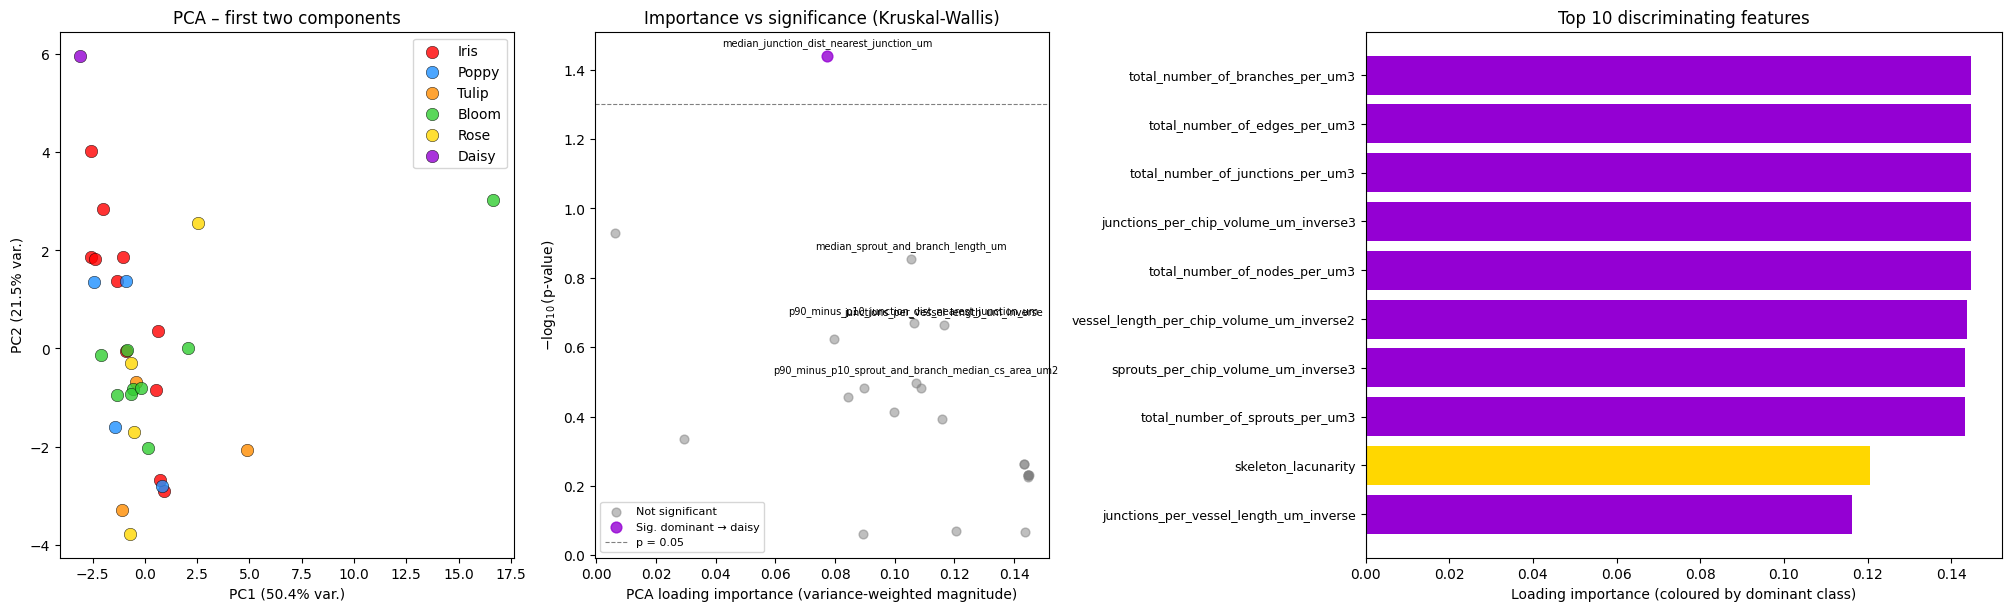

Significant features: 1 / 23


In [15]:
significant_params, top_params = pca_plots(
    combined_analysis_metrics_minimal[combined_analysis_metrics_minimal["experiment"] != "WW"],
    CONDITION_COLORS, save_dir=output_dir,
)

Saved: Z:\Bel\Individual_Vascumap_Outputs\Avalon_Vascumap\To_Analyse_output_data\significant_changes.png


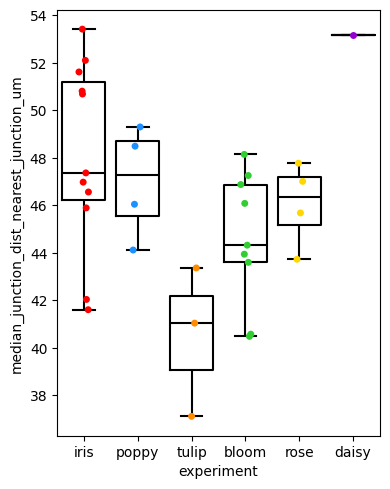

In [16]:
xorder = [c for c in CONDITION_COLORS if c in combined_analysis_metrics_minimal["experiment"].unique()]
plot_experiment_comparisons(
    combined_analysis_metrics_minimal[combined_analysis_metrics_minimal["experiment"] != "WW"],
    significant_params[:5], xorder, "significant_changes", output_dir, CONDITION_COLORS,
)

Saved: Z:\Bel\Individual_Vascumap_Outputs\Avalon_Vascumap\To_Analyse_output_data\top_params.png


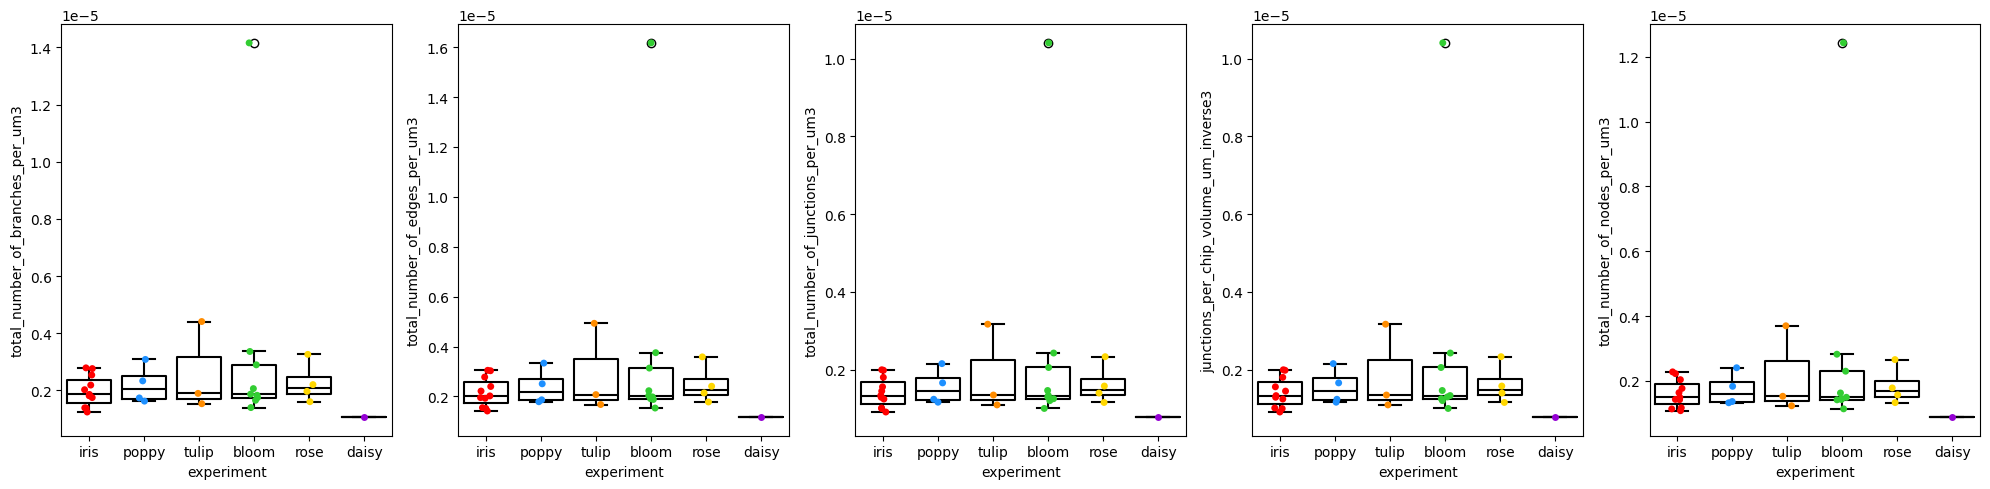

In [12]:
plot_experiment_comparisons(
    combined_analysis_metrics_minimal,
    top_params[:5], xorder, "top_params", output_dir, CONDITION_COLORS,
)